In [1]:
# Análise de Dados do ENEM 2021

# Este código realiza uma análise dos resultados do Exame Nacional do Ensino Médio (ENEM)
# com base em dados educacionais por cidade do Brasil.




In [2]:
# Bibliotecas necessárias
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
# Selecionando apenas as colunas que serão utilizadas

colunas = ['NU_INSCRICAO', 'TP_FAIXA_ETARIA',
          'TP_SEXO', 'TP_SEXO', 'TP_ESTADO_CIVIL',
           'TP_COR_RACA','TP_NACIONALIDADE', 'TP_SEXO', 'NO_MUNICIPIO_PROVA', 'SG_UF_PROVA',
           'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT','NU_NOTA_REDACAO']

# Lendo o arquivo CSV e filtrando as colunas desejadas
df_microdados = pd.read_csv('MICRODADOS_ENEM_2021.csv', encoding='latin-1', sep=';', usecols=colunas)

In [4]:
df_microdados.head()

,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,NO_MUNICIPIO_PROVA,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
0,210053865474,5,F,1,1,1,Nova Lima,MG,NaN,574.6,472.6,NaN,760.0
1,210052384164,12,M,1,1,1,Maceió,AL,505.9,551.8,498.3,461.5,560.0
2,210052589243,13,F,3,1,1,Ferraz de Vasconcelos,SP,NaN,NaN,NaN,NaN,NaN
3,210052128335,3,M,1,3,1,Crato,CE,580.7,678.9,638.9,659.5,780.0
4,210051353021,2,F,1,3,1,Acarape,CE,497.7,532.4,457.6,582.6,780.0


In [5]:
# Exibindo informações sobre o dataframe
df_microdados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3389832 entries, 0 to 3389831
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   NU_INSCRICAO        int64  
 1   TP_FAIXA_ETARIA     int64  
 2   TP_SEXO             object 
 3   TP_ESTADO_CIVIL     int64  
 4   TP_COR_RACA         int64  
 5   TP_NACIONALIDADE    int64  
 6   NO_MUNICIPIO_PROVA  object 
 7   SG_UF_PROVA         object 
 8   NU_NOTA_CN          float64
 9   NU_NOTA_CH          float64
 10  NU_NOTA_LC          float64
 11  NU_NOTA_MT          float64
 12  NU_NOTA_REDACAO     float64
dtypes: float64(5), int64(5), object(3)
memory usage: 336.2+ MB


In [6]:
# Contando o número de linhas e colunas no dataframe
num_rows, num_cols = df_microdados.shape
print(f"Número de linhas: {num_rows}")
print(f"Número de atributos: {num_cols}")


Número de linhas: 3389832
Número de atributos: 13


In [7]:
# Mapeando valores para algumas colunas do dataframe
tp_faixa_etaria_map = {
    1: "Menor de 17 anos",
    2: "17 anos",
    3: "18 anos",
    4: "19 anos",
    5: "20 anos",
    6: "21 anos",
    7: "22 anos",
    8: "23 anos",
    9: "24 anos",
    10: "25 anos",
    11: "Entre 26 e 30 anos",
    12: "Entre 31 e 35 anos",
    13: "Entre 36 e 40 anos",
    14: "Entre 41 e 45 anos",
    15: "Entre 46 e 50 anos",
    16: "Entre 51 e 55 anos",
    17: "Entre 56 e 60 anos",
    18: "Entre 61 e 65 anos",
    19: "Entre 66 e 70 anos",
    20: "Maior de 70 anos",
}

tp_sexo_map = {"F": "Feminino", "M": "Masculino"}

tp_estadocivil_map = {
    0: "Não informado",
    1: "Solteiro(a)",
    2: "Casado(a)/Mora com companheiro(a)",
    3: "Divorciado(a)/Desquitado(a)/Separado(a)",
    4: "Viúvo(a)",
}


tp_cor_raca_map = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena",
    6: "Não dispõe da informação",
}

tp_nacionalidade_map = {
    0: "Não informado",
    1: "Brasileiro(a)",
    2: "Brasileiro(a) Naturalizado(a)",
    3: "Estrangeiro(a)",
    4: "Brasileiro(a) Nato(a), nascido(a) no exterior",
}


In [8]:
# Função para substituir valores nas colunas usando dicionários de mapeamento
def substituir_valores(coluna, mapeamento):
    df_microdados[coluna] = df_microdados[coluna].replace(mapeamento)

# Substituindo valores usando os dicionários de mapeamento
substituir_valores('TP_FAIXA_ETARIA', tp_faixa_etaria_map)
substituir_valores('TP_SEXO', tp_sexo_map)
substituir_valores('TP_ESTADO_CIVIL', tp_estadocivil_map)
substituir_valores('TP_COR_RACA', tp_cor_raca_map)
substituir_valores('TP_NACIONALIDADE', tp_nacionalidade_map)

In [9]:
df_microdados.head()

,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,NO_MUNICIPIO_PROVA,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
0,210053865474,20 anos,Feminino,Solteiro(a),Branca,Brasileiro(a),Nova Lima,MG,NaN,574.6,472.6,NaN,760.0
1,210052384164,Entre 31 e 35 anos,Masculino,Solteiro(a),Branca,Brasileiro(a),Maceió,AL,505.9,551.8,498.3,461.5,560.0
2,210052589243,Entre 36 e 40 anos,Feminino,Divorciado(a)/Desquitado(a)/Separado(a),Branca,Brasileiro(a),Ferraz de Vasconcelos,SP,NaN,NaN,NaN,NaN,NaN
3,210052128335,18 anos,Masculino,Solteiro(a),Parda,Brasileiro(a),Crato,CE,580.7,678.9,638.9,659.5,780.0
4,210051353021,17 anos,Feminino,Solteiro(a),Parda,Brasileiro(a),Acarape,CE,497.7,532.4,457.6,582.6,780.0


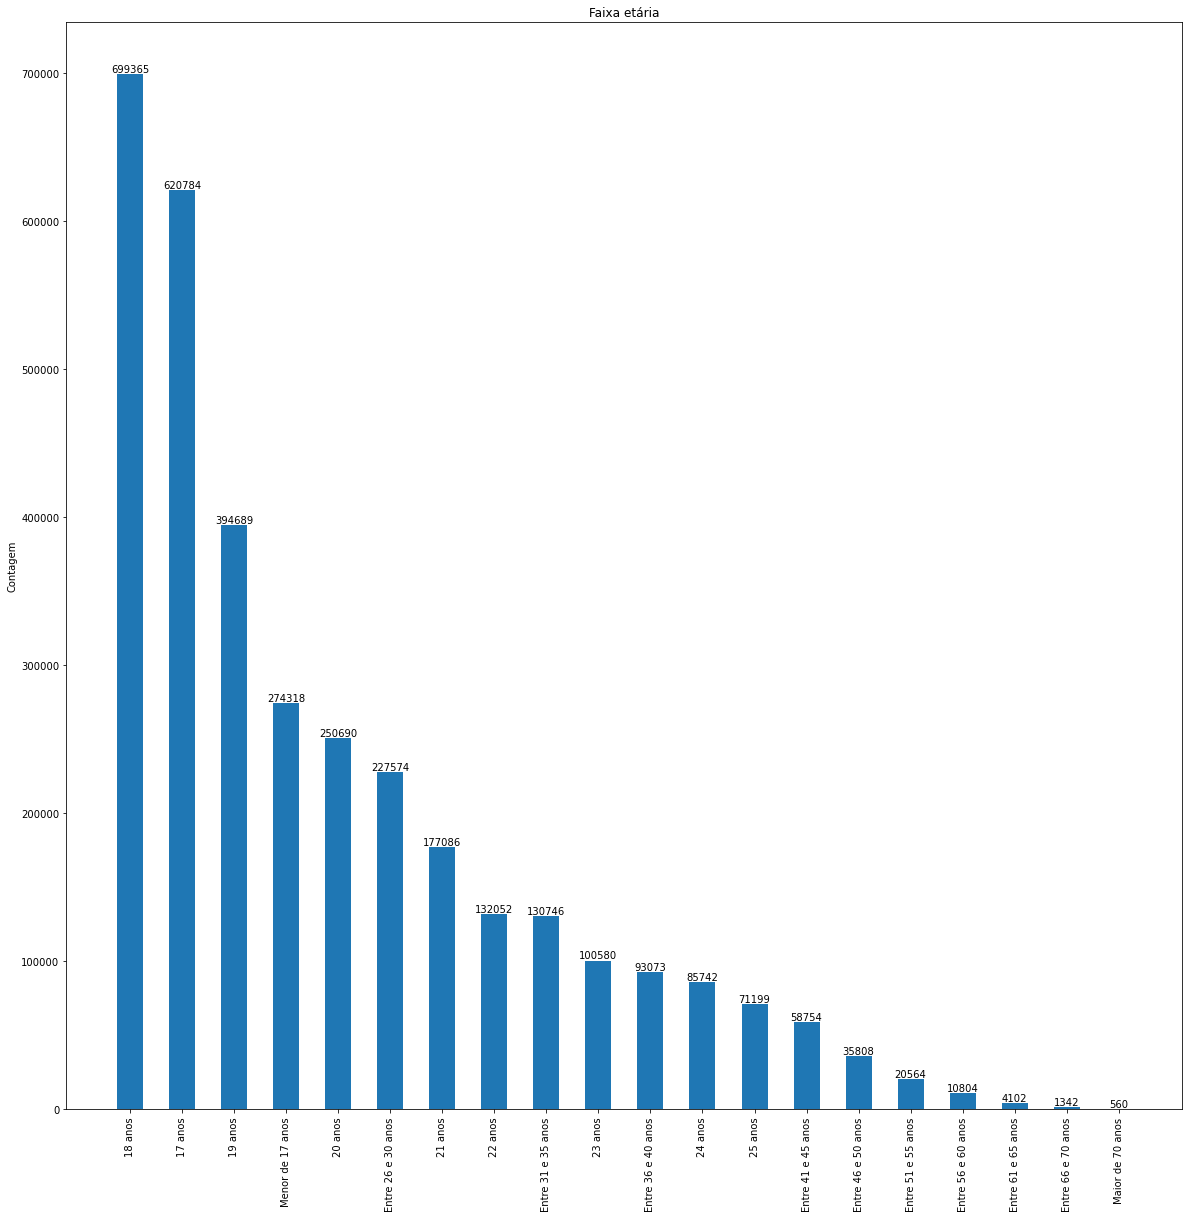

In [10]:
# Visualizando a distribuição da faixa etária em um gráfico de barras
faixa_etaria = df_microdados['TP_FAIXA_ETARIA'].value_counts()
x = faixa_etaria.index
y = faixa_etaria.values
plt.figure(figsize=(20, 20))
z = plt.bar(x, y, width=0.5)
plt.bar_label(z, labels=y)
plt.title('Faixa etária')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.show()

<AxesSubplot:ylabel='TP_SEXO'>

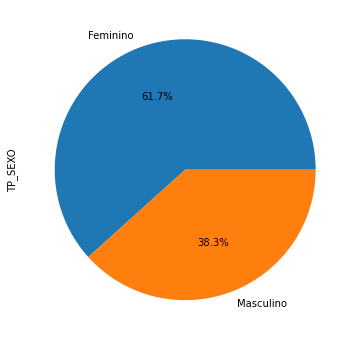

In [11]:
# Plotando um gráfico de pizza para visualizar a distribuição de 'TP_SEXO'
contagem = df_microdados['TP_SEXO'].value_counts()
total = len(contagem)
df_microdados['TP_SEXO'].value_counts().plot(kind='pie', figsize=(12, 6), autopct='%1.1f%%')


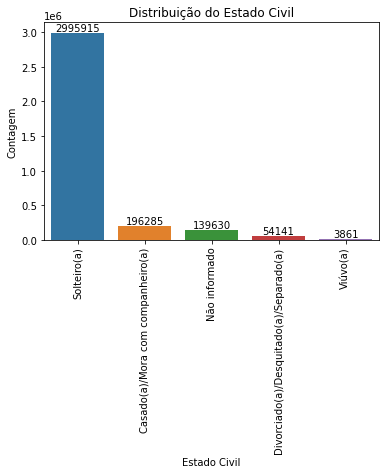

In [12]:
# Visualizando a distribuição de estado civil em um gráfico de barras
contagens = df_microdados['TP_ESTADO_CIVIL'].value_counts()
contagens_df = contagens.reset_index()
contagens_df.columns = ['TP_ESTADO_CIVIL', 'contagem']
sns.barplot(x='TP_ESTADO_CIVIL', y='contagem', data=contagens_df)

# Adicionando valores nas barras
for index, value in enumerate(contagens_df['contagem']):
    plt.annotate(str(value), xy=(index, value), ha='center', va='bottom')

plt.xlabel('Estado Civil') 
plt.ylabel('Contagem')  
plt.title('Distribuição do Estado Civil')  
plt.xticks(rotation=90)  
plt.show()

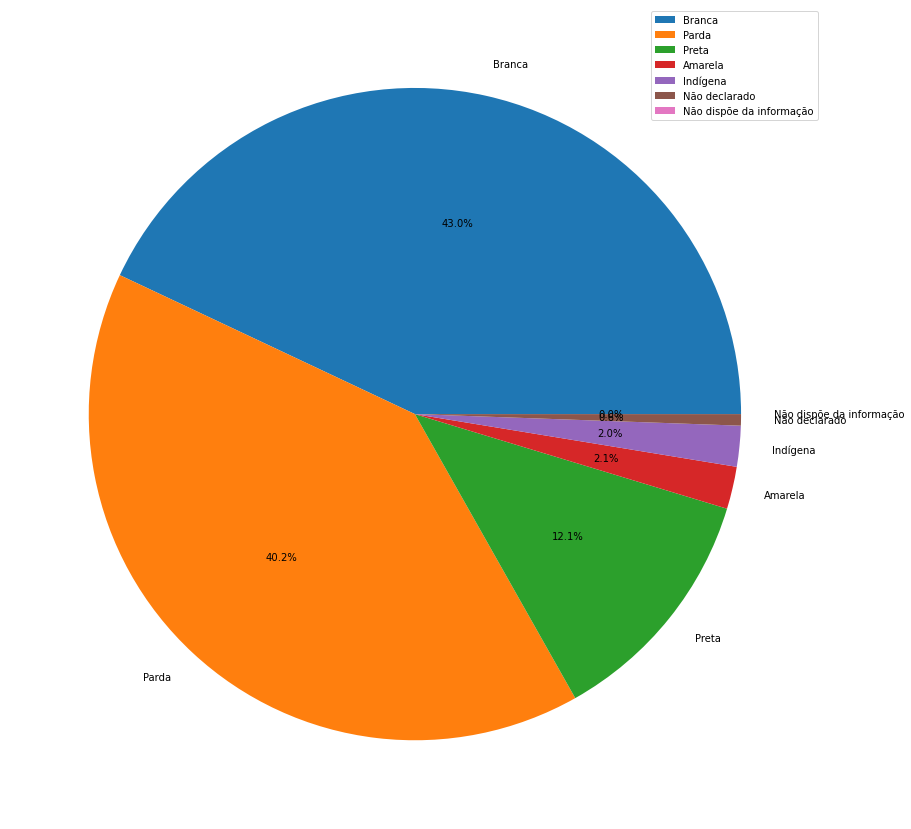

In [13]:
# Plotando um gráfico de pizza para visualizar a distribuição de 'TP_COR_RACA'
labels = df_microdados['TP_COR_RACA'].unique()
tamanhos = df_microdados['TP_COR_RACA'].value_counts()

plt.figure(figsize=(15, 15))
plt.pie(tamanhos, labels=labels, autopct='%1.1f%%')
plt.legend(loc="upper right")
plt.show()

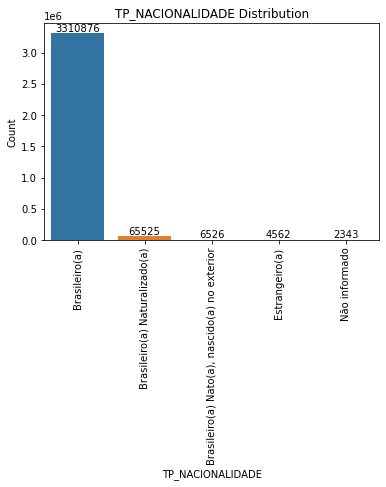

In [14]:
# Plotando o gráfico de barras para 'TP_NACIONALIDADE'
contagens = df_microdados['TP_NACIONALIDADE'].value_counts()
contagens_df = contagens.reset_index()
contagens_df.columns = ['TP_NACIONALIDADE', 'contagem']


sns.barplot(x='TP_NACIONALIDADE', y='contagem', data=contagens_df)

# Adicionando valores nas barras
for index, value in enumerate(contagens_df['contagem']):
    plt.annotate(str(value), xy=(index, value), ha='center', va='bottom')

plt.xlabel('TP_NACIONALIDADE') 
plt.ylabel('Count')  
plt.title('TP_NACIONALIDADE Distribution')  
plt.xticks(rotation=90) 
plt.show()

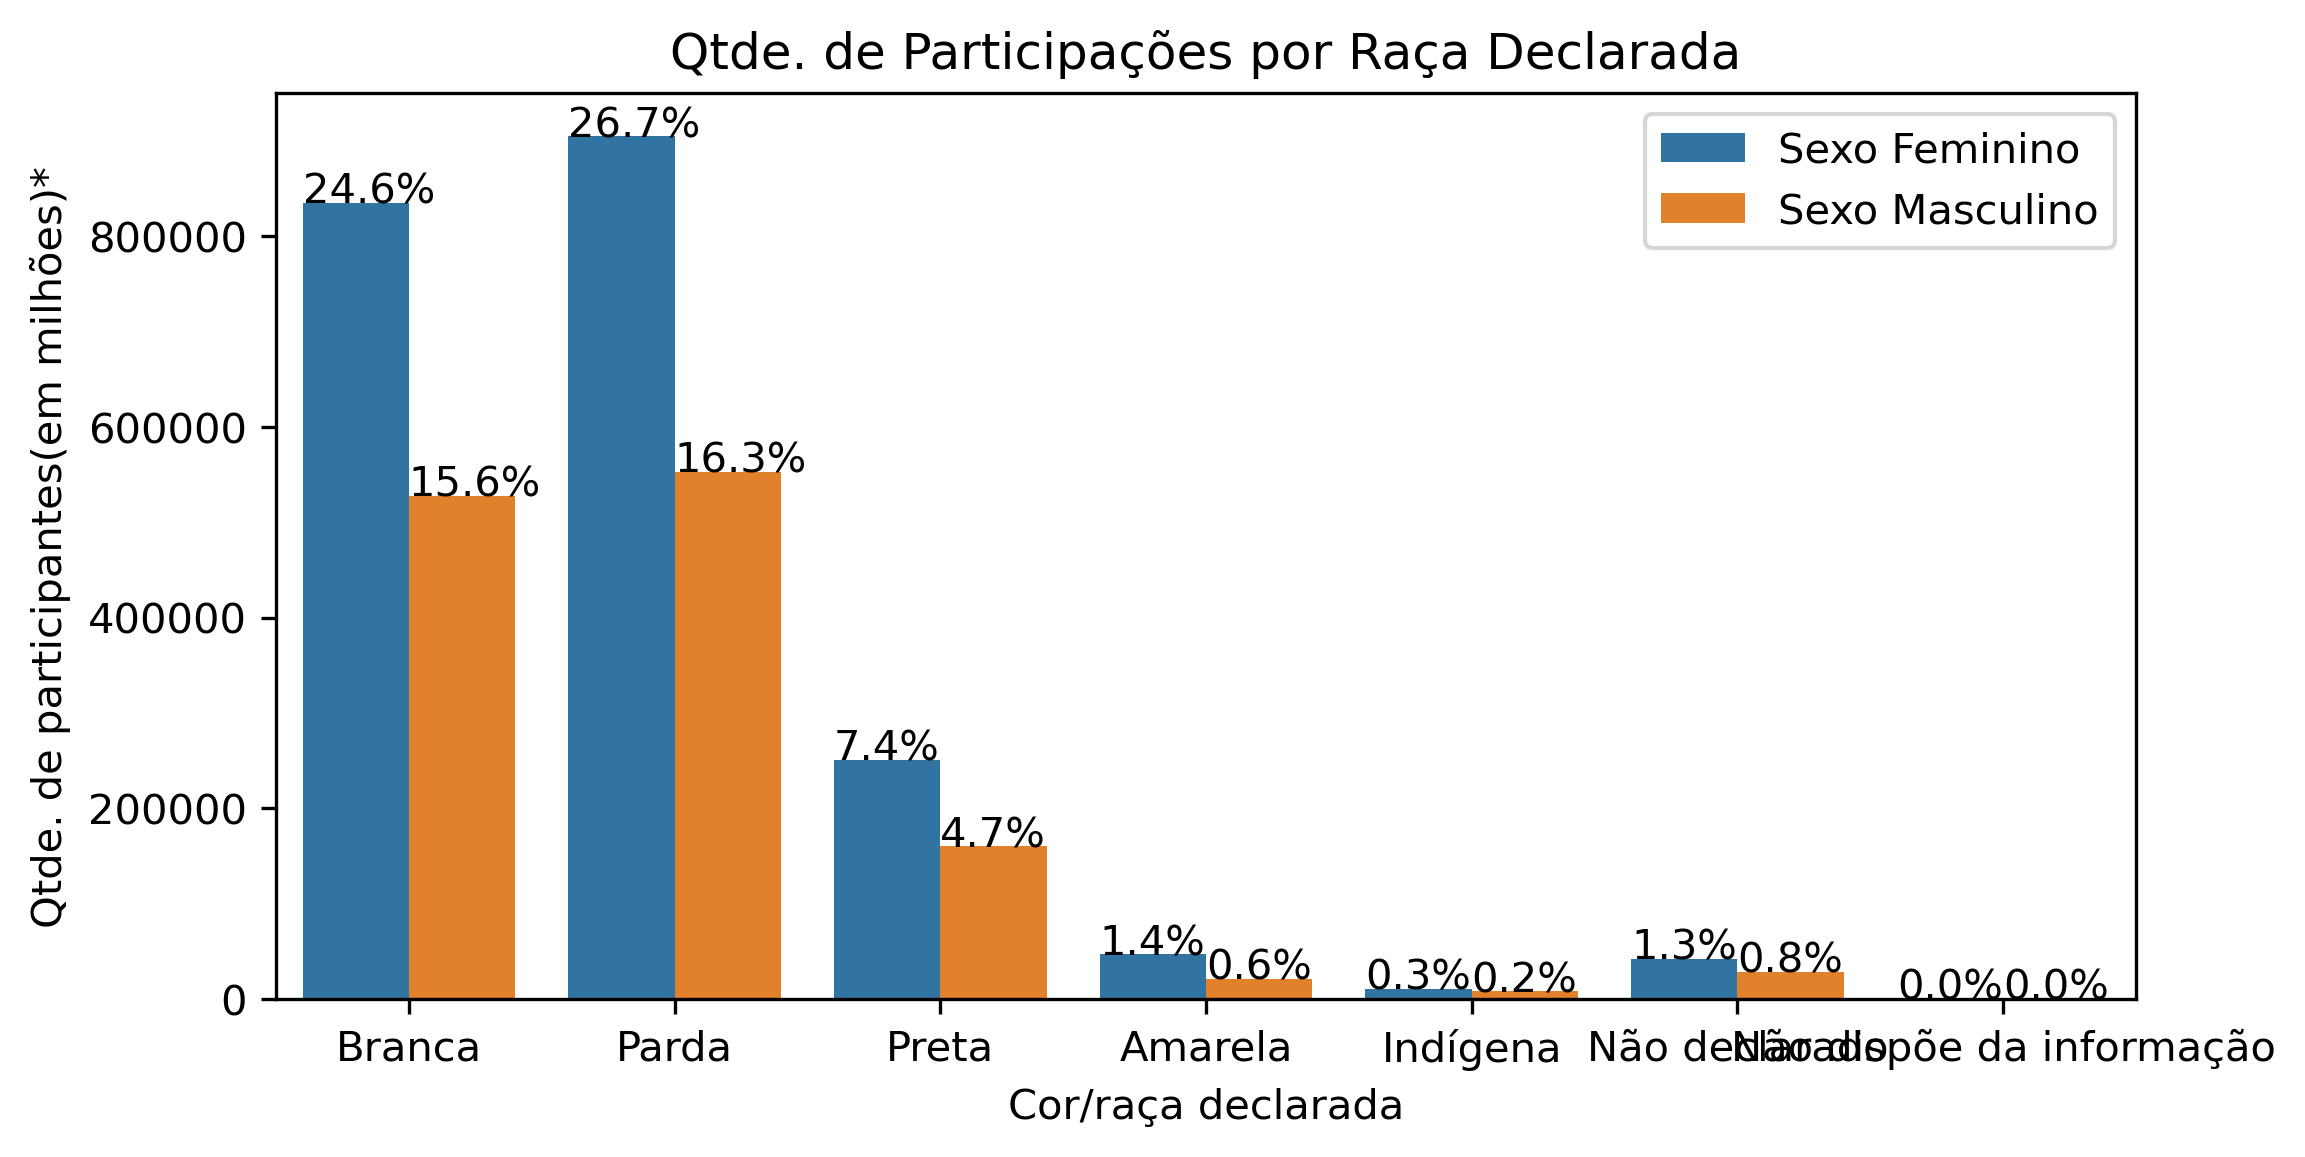

In [15]:
# Plotar o gráfico de barras de quantidade de participações por raça

fig, ax = plt.subplots(dpi=300, figsize=(8, 4))


sns.countplot(data=df_microdados, x="TP_COR_RACA",hue="TP_SEXO", ax=ax)

# Adicionando porcentagens em cima das barras 
for c in ax.containers:
    for v in c:
        bar_height = v.get_height() # altura da barra
        x_value = v.get_x() # valor da barra no eixo x
        text = "{:.1%}".format(bar_height/len(df_microdados))
        ax.annotate(xy=(x_value, bar_height), text=text)
    
 # editando labels, titles e etc. 
ax.set_title("Qtde. de Participações por Raça Declarada")
ax.set_ylabel("Qtde. de participantes(em milhões)*")
ax.set_xlabel("Cor/raça declarada") 
ax.legend(["Sexo Feminino", "Sexo Masculino"])


plt.show()

In [16]:
#Quantidade de candidatos por estado

uf_prova = df_microdados['SG_UF_PROVA']
uf_prova.value_counts()

SP    509954
MG    327829
BA    266194
RJ    238347
CE    220517
PE    193616
PA    185978
RS    150484
PR    144282
GO    136915
MA    127905
PB    102002
AM     89778
RN     80820
SC     80765
PI     79969
DF     67501
ES     64181
AL     56584
MT     56085
SE     53796
MS     42490
RO     32801
TO     30873
AP     21774
AC     20336
RR      8056
Name: SG_UF_PROVA, dtype: int64

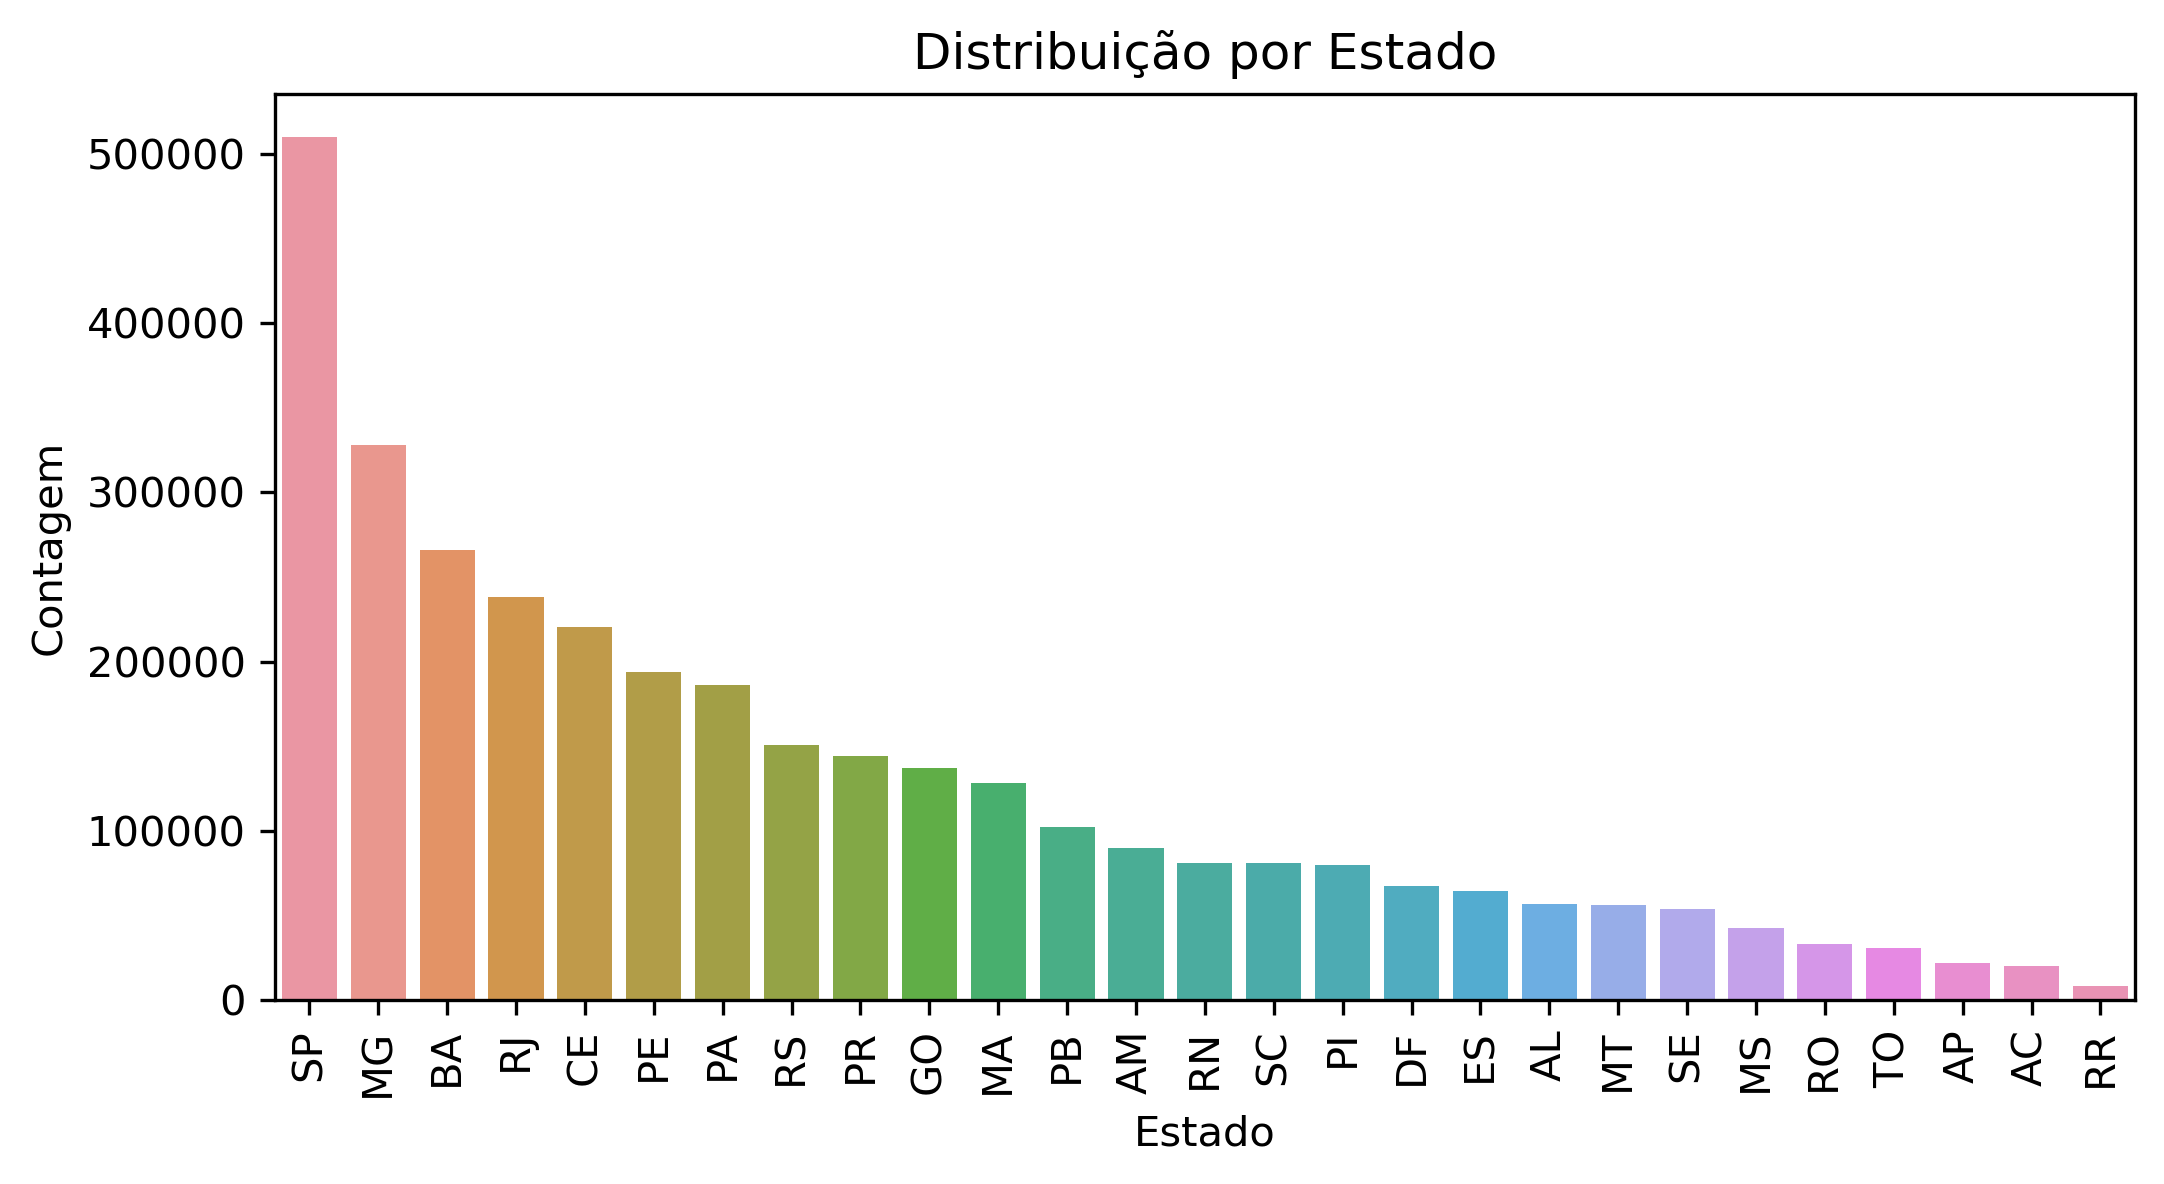

In [17]:
# Plotar o gráfico de barras para quantidade de participantes por estado

fig, ax = plt.subplots(dpi=300, figsize=(8, 4))
contagens = df_microdados['SG_UF_PROVA'].value_counts()
contagens_df = contagens.reset_index()
contagens_df.columns = ['SG_UF_PROVA', 'contagem']


sns.barplot(x='SG_UF_PROVA', y='contagem', data=contagens_df, ax=ax)

plt.xlabel('Estado') 
plt.ylabel('Contagem') 
plt.title('Distribuição por Estado')  
plt.xticks(rotation=90) 
plt.show()

In [18]:
# Calcular as médias das notas para cada cidade e estado
mean_scores = round(df_microdados.groupby(['NO_MUNICIPIO_PROVA', 'SG_UF_PROVA'])[['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']].mean(), 2)
mean_scores.head()

,,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
NO_MUNICIPIO_PROVA,SG_UF_PROVA,,,,,
Abaetetuba,PA,460.11,479.57,459.22,479.54,588.53
Abaeté,MG,498.35,519.27,508.30,548.98,634.77
Abreu e Lima,PE,470.48,495.58,484.55,499.65,575.24
Acarape,CE,461.06,479.32,468.50,486.66,571.46
Acaraú,CE,454.66,471.92,469.66,500.03,557.75


In [19]:
# Passo 2: Ordenar os dados para obter as 10 maiores e 10 menores médias por cidade
top_10_medias = mean_scores.nlargest(10, ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO'])
bottom_10_medias = mean_scores.nsmallest(10, ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO'])


In [20]:
# Calcular as médias das notas para cada estado
mean_scores_estado = round(df_microdados.groupby('SG_UF_PROVA')[['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']].mean(), 2)
mean_scores_estado.head()

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
SG_UF_PROVA,,,,,
AC,469.59,497.73,482.73,495.79,580.49
AL,476.64,501.64,484.53,516.80,608.84
AM,460.33,482.04,468.70,486.21,529.63
AP,467.70,495.45,473.61,491.37,572.17
BA,479.94,506.23,489.13,513.51,606.28


In [21]:
# Ordenar os dados para obter as 10 maiores e 10 menores médias por estado
top_10_medias_estado = mean_scores_estado.nlargest(10, ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO'])
bottom_10_medias_estado =  mean_scores_estado.nsmallest(10, ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO'])

In [22]:
# Define uma função para mapear estados para suas respectivas regiões
def map_regioes_brasil(estado):
    if estado in ['AM', 'RR', 'AP', 'PA', 'TO', 'RO', 'AC']:
        return 'Norte'
    elif estado in ['MA', 'PI', 'CE', 'RN', 'PB', 'PE', 'AL', 'SE', 'BA']:
        return 'Nordeste'
    elif estado in ['MT', 'MS', 'GO', 'DF']:
        return 'Centro-Oeste'
    elif estado in ['SP', 'RJ', 'ES', 'MG']:
        return 'Sudeste'
    elif estado in ['PR', 'RS', 'SC']:
        return 'Sul'


In [23]:
# Adiciona uma nova coluna 'REGIÃO' ao dataframe, mapeando cada estado para sua respectiva região
df_microdados['REGIÃO'] = df_microdados['SG_UF_PROVA'].apply(map_regioes_brasil)

medias_por_regiao =  round(df_microdados.groupby('REGIÃO')[['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']].mean(), 2)

# Passo 2: Ordenar os dados para obter as 10 maiores e 10 menores médias por regiao
top_10_medias_regiao = medias_por_regiao.nlargest(10, ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO'])
bottom_10_medias_regiao = medias_por_regiao.nsmallest(10, ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO'])


In [24]:
df_cidades = pd.read_csv('cidades.csv')

df_cidades.head()

,Município,Código,Gentílico,Prefeito_2017,Área_Territorial_2018,População_estimada_pessoas_2019,Densidade_demográfica_2010,Escolarização_6_a_14_anos_%_2010,IDHMunicipal_2010,Mortalidade_infantil_óbitos_por_mil_nascidos_vivos_2017,Receitas_realizadas_×1000_2017,Despesas_empenhadas_×1000_2017,PIB_per_capita_2017
0,Adamantina,3500105,adamantinense,MÁRCIO CARDIM,"411,987",35068,"82,15","97,6","0,79","11,63","160718,6793","137083,6699","30010,56"
1,Adolfo,3500204,adolfino,IZAEL ANTONIO FERNANDES,"211,055",3562,"16,85","98,6","0,73","19,23","27333,74731","20103,87713","27634,98"
2,Aguaí,3500303,aguaiano,JOSÉ ALEXANDRE PEREIRA DE ARAÚJO,"474,554",36305,"67,72","95,8","0,715","16,06","84094,76006","72168,73408","26549,19"
3,Águas da Prata,3500402,pratense,CARLOS HENRIQUE FORTES DEZENA,"142,673",8180,"53,05","98,8","0,781","25,32","29390,24814","24363,40149","18974,98"
4,Águas de Lindóia,3500501,lindoiense,GILBERTO ABDOU HELOU,"60,126",18705,"287,16","96,2","0,745","8,37","86949,22213","75201,47793","25554,26"


In [25]:
# Seleciona as colunas desejadas do DataFrame
nome_coluna_chave = 'Município'  # Coluna a ser usada como chave
nome_coluna_valor = 'População_estimada_pessoas_2019'  

colunas_selecionadas = df_cidades[[nome_coluna_chave, nome_coluna_valor]]

# Cria um dicionário Python 
dados_populacao = dict(zip(colunas_selecionadas[nome_coluna_chave], colunas_selecionadas[nome_coluna_valor]))

# Dicionario das cidades e sua população
print(dados_populacao)


{'Adamantina': 35068, 'Adolfo': 3562, 'Aguaí': 36305, 'Águas da Prata': 8180, 'Águas de Lindóia': 18705, 'Águas de Santa Bárbara': 6075, 'Águas de São Pedro': 3451, 'Agudos': 37214, 'Alambari': 6025, 'Alfredo Marcondes': 4166, 'Altair': 4160, 'Altinópolis': 16184, 'Alto Alegre': 1638, 'Alumínio': 18628, 'Álvares Florence': 3679, 'Álvares Machado': 24915, 'Álvaro de Carvalho': 5227, 'Alvinlândia': 3222, 'Americana': 239597, 'Américo Brasiliense': 40504, 'Américo de Campos': 5969, 'Amparo': 2238, 'Analândia': 4995, 'Andradina': 57157, 'Angatuba': 25228, 'Anhembi': 6724, 'Anhumas': 4115, 'Aparecida': 8347, "Aparecida d'Oeste": 4196, 'Apiaí': 24374, 'Araçariguama': 22364, 'Araçatuba': 197016, 'Araçoiaba da Serra': 34146, 'Aramina': 5620, 'Arandu': 6357, 'Arapeí': 2469, 'Araraquara': 236072, 'Araras': 134236, 'Arco-Íris': 1791, 'Arealva': 8560, 'Areias': 3886, 'Areiópolis': 11129, 'Ariranha': 9668, 'Artur Nogueira': 54408, 'Arujá': 89824, 'Aspásia': 1822, 'Assis': 104386, 'Atibaia': 142761,

In [26]:
# Adicionar os dados de população ao dataframe 'df_microdados' usando a coluna 'NO_MUNICIPIO_PROVA' como chave
df_microdados['População'] = df_microdados['NO_MUNICIPIO_PROVA'].map(dados_populacao)


In [27]:
# Calcular as médias das notas por região do Brasil
medias_por_regiao = round(df_microdados.groupby('REGIÃO')[['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']].mean(), 2)

In [28]:
# Salvar os resultados em DataFrames
mean_scores.to_excel('Output/Media_por_cidade.xlsx')

top_10_medias.to_excel('Output/top_10_scores_por_cidade.xlsx')
bottom_10_medias.to_excel('Output/top_10_scores_por_cidade.xlsx')

top_10_medias_estado.to_excel('Output/top_10_scores_por_estado.xlsx')
bottom_10_medias_estado.to_excel('Output/bottom_10_scores_por_estado.xlsx')

top_10_medias_regiao.to_excel('Output/top_10_medias_por_regiao.xlsx')
bottom_10_medias_regiao.to_excel('Output/bottom_10_medias_por_regiao.xlsx')

df_microdados.to_csv('Output/df_microdados.csv')
medias_por_regiao.to_excel('Output/Media_por_regiao.xlsx')

In [ ]:
%store mean_scores
